# Data Extraction from YFinance Library


Welcome to this introductory notebook on financial data analysis with Python.

### Learning objectives
- Understand what a **ticker** is and how market symbols identify assets.
- Download historical data with `yfinance` in a reproducible way.
- Read the structure of a financial DataFrame (OHLCV + adjusted price).
- Compute and interpret simple returns and log-returns.
- Calculate basic statistics such as average return and volatility.

### What we will build by the end
- A simple data pipeline to download, inspect, and transform market prices.
- Clear charts for adjusted prices and return behavior.
- A first comparison workflow between two assets (SPY and AAPL).

### Educational note
This notebook is for **education only**. It is **not financial advice** and does not recommend buying or selling any asset.


## 1. Environment setup (Google Colab)

Before writing analysis code, it is useful to understand two basic ideas:

- A **library** is a collection of tools created by other developers.
- **Installing** a library means adding it to your Python environment.
- **Importing** a library means making it available inside your notebook code.

In Google Colab, installation usually happens with `pip`, and imports use statements like `import pandas as pd`.

This separation is important:
- Install once per environment/session.
- Import each time you run the notebook from top to bottom.


In [ ]:
# 2. Installation (if needed)
# In Colab, installing packages with pip inside a cell is a common workflow.
# This block checks if yfinance is available, and installs it only if missing.

import importlib.util

if importlib.util.find_spec("yfinance") is None:
    print("yfinance not found. Installing...")
    !pip -q install yfinance
else:
    print("yfinance is already installed.")


yfinance is already installed.


In [ ]:
# 3. Imports
# We import the libraries used throughout this notebook.

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Plot settings for readability.
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

# Reproducibility seed (good practice even if randomness is not central here).
np.random.seed(42)


## 4. What is a ticker? What is yfinance?

A **ticker** is a short symbol used in financial markets to identify an asset.

Examples:
- `SPY`: ETF linked to the S&P 500.
- `AAPL`: Apple stock.
- `MSFT`: Microsoft stock.
- `^GSPC`: S&P 500 index symbol in Yahoo Finance.

`yfinance` is a Python library that downloads historical market data from Yahoo Finance into a table structure (a DataFrame), which we can analyze with pandas.


In [ ]:
# 5. Download data for one asset (SPY)
# We download daily SPY data from 2018-01-01 onward.
# auto_adjust=False keeps both Close and Adj Close columns available.

data = yf.download("SPY", start="2018-01-01", auto_adjust=False, progress=False)

# Show first rows to inspect structure.
data.head()

# Typical columns:
# Open      -> opening price of the day
# High      -> highest traded price of the day
# Low       -> lowest traded price of the day
# Close     -> closing price of the day (raw)
# Adj Close -> close adjusted for dividends/splits
# Volume    -> number of traded shares/contracts


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY,SPY
Date,,,,,,
2018-01-02,236.562134,268.769989,268.809998,267.399994,267.839996,86655700
2018-01-03,238.058456,270.470001,270.640015,268.959991,268.959991,90070400
2018-01-04,239.061829,271.609985,272.160004,270.540009,271.200012,80636400
2018-01-05,240.654953,273.420013,273.559998,271.950012,272.510010,83524000
2018-01-08,241.095047,273.920013,274.100006,272.980011,273.309998,57319200


## 6. Close vs Adj Close (very important)

Understanding this difference is essential for return analysis:

- **Close** is the raw daily closing price.
- **Adj Close** adjusts historical prices for events such as dividends and stock splits.

Why do we usually prefer `Adj Close` for performance analysis?

Because returns should reflect the real economic evolution of holding the asset over time. Adjusted prices make different dates more comparable.


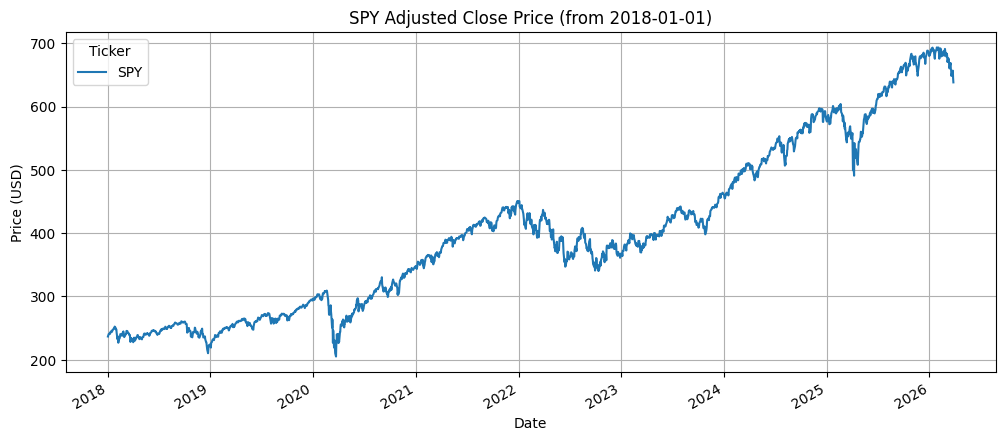

In [ ]:
# 7. Plot adjusted price
# We plot the adjusted close to visualize long-run price evolution.

data["Adj Close"].plot()
plt.title("SPY Adjusted Close Price (from 2018-01-01)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(True)
plt.show()


## 8. Returns: what they are and why they matter

A **return** expresses relative change between two periods.

- **Simple return** (`pct_change`):
  - Formula: `(Price_t / Price_{t-1}) - 1`
- **Log-return**:
  - Formula: `log(Price_t) - log(Price_{t-1})`

Why work with returns instead of prices?
- Returns are naturally scale-free (percent-like).
- They are easier to compare across assets with different price levels.


In [ ]:
# 9. Compute simple and log returns
# Simple daily return from adjusted close.
data["ret"] = data["Adj Close"].pct_change()

# Log daily return from adjusted close.
data["log_ret"] = np.log(data["Adj Close"]).diff()

# First row is NaN because there is no previous day for comparison.
data.head()


Price,Adj Close,Close,High,Low,Open,Volume,ret,log_ret
Ticker,SPY,SPY,SPY,SPY,SPY,SPY,,
Date,,,,,,,,
2018-01-02,236.562134,268.769989,268.809998,267.399994,267.839996,86655700,NaN,NaN
2018-01-03,238.058456,270.470001,270.640015,268.959991,268.959991,90070400,0.006325,0.006305
2018-01-04,239.061829,271.609985,272.160004,270.540009,271.200012,80636400,0.004215,0.004206
2018-01-05,240.654953,273.420013,273.559998,271.950012,272.510010,83524000,0.006664,0.006642
2018-01-08,241.095047,273.920013,274.100006,272.980011,273.309998,57319200,0.001829,0.001827


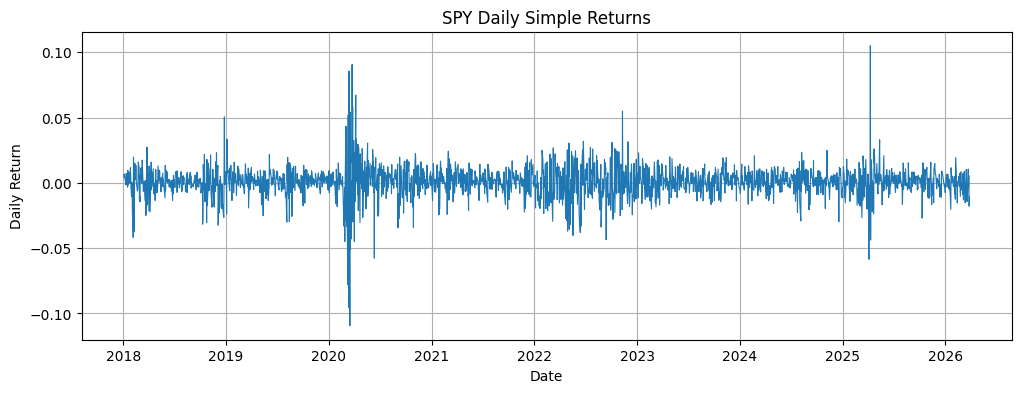

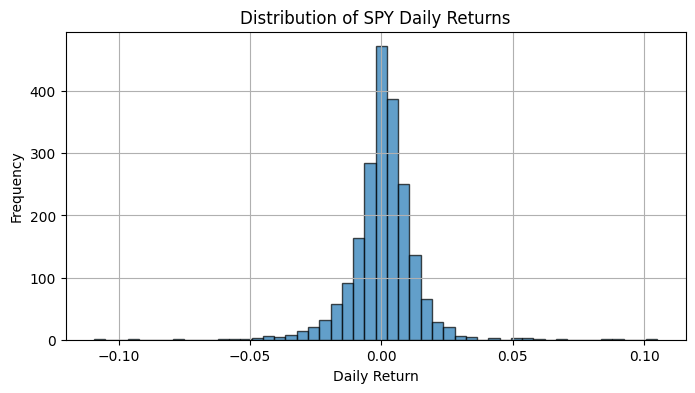

In [ ]:
# 10. Plot returns
# We remove NaN values before plotting returns.
ret_series = data["ret"].dropna()

# Time-series line plot of daily returns.
plt.figure(figsize=(12, 4))
plt.plot(ret_series.index, ret_series.values, linewidth=0.8)
plt.title("SPY Daily Simple Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.grid(True)
plt.show()

# Histogram to inspect distribution shape.
plt.figure(figsize=(8, 4))
plt.hist(ret_series, bins=50, edgecolor="black", alpha=0.7)
plt.title("Distribution of SPY Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


## 11. Basic metrics: mean and volatility

Two foundational summary metrics are:

- **Mean daily return**: average of daily returns.
- **Daily volatility**: standard deviation of daily returns (how much returns fluctuate).

To convert daily volatility to an annual scale, a common approximation is:

`annual volatility = daily volatility * sqrt(252)`

Why 252?
A typical trading year has around 252 market days (excluding weekends and major market holidays).


In [ ]:
# 12. Compute mean and volatility (daily and annualized)
# Compute basic statistics from simple returns.
mean_ret = data["ret"].mean()
vol_daily = data["ret"].std()
vol_annual = vol_daily * np.sqrt(252)

# Friendly output format.
print(f"Mean daily return: {mean_ret:.6f} ({mean_ret*100:.4f}%)")
print(f"Daily volatility: {vol_daily:.6f} ({vol_daily*100:.4f}%)")
print(f"Annualized volatility (approx): {vol_annual:.6f} ({vol_annual*100:.2f}%)")


Mean daily return: 0.000554 (0.0554%)
Daily volatility: 0.012161 (1.2161%)
Annualized volatility (approx): 0.193050 (19.31%)


## 13. Compare 2 assets (SPY vs AAPL)

Comparing assets helps us think in terms of:

- **Return path**: how each series evolves through time.
- **Risk profile**: how unstable or variable daily returns are.

We will compare SPY and AAPL using normalized adjusted prices and a volatility summary.

This is an educational comparison, not an investment recommendation.


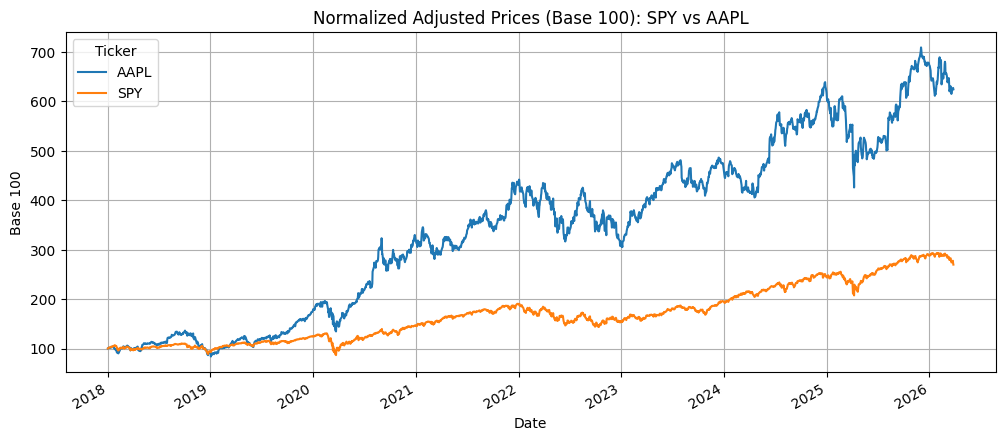

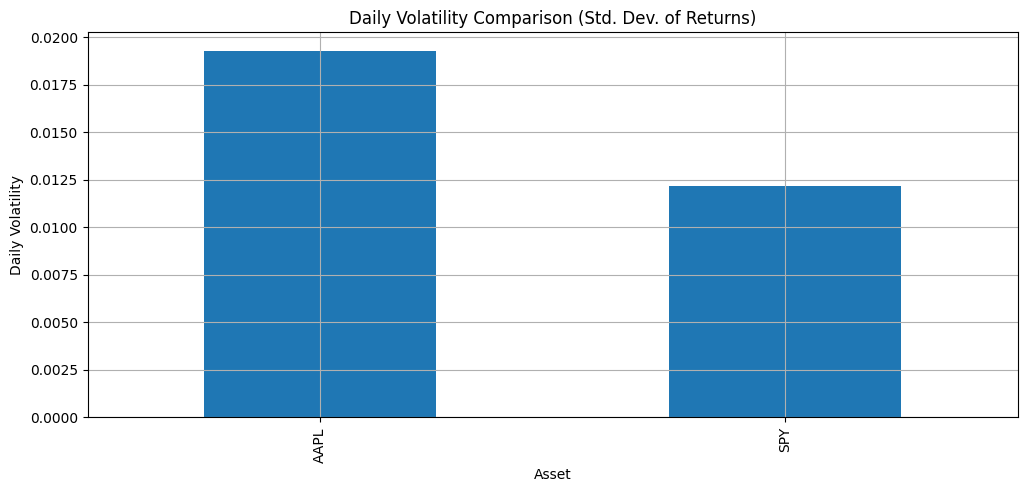

Daily volatility by asset:
Ticker
AAPL    0.019294
SPY     0.012161
dtype: float64


In [ ]:
# 14. Download and compare SPY vs AAPL
# Download both tickers in one call.
tickers = ["SPY", "AAPL"]
multi_data = yf.download(tickers, start="2018-01-01", auto_adjust=False, progress=False)

# Keep adjusted close prices only.
adj_close = multi_data["Adj Close"].copy()

# Compute daily simple returns for both assets.
rets = adj_close.pct_change().dropna()

# Normalize prices to base 100 for visual comparison.
norm_prices = adj_close / adj_close.iloc[0] * 100
norm_prices.plot()
plt.title("Normalized Adjusted Prices (Base 100): SPY vs AAPL")
plt.xlabel("Date")
plt.ylabel("Base 100")
plt.grid(True)
plt.show()

# Compare daily volatility values.
vol_compare = rets.std().sort_values(ascending=False)
vol_compare.plot(kind="bar")
plt.title("Daily Volatility Comparison (Std. Dev. of Returns)")
plt.xlabel("Asset")
plt.ylabel("Daily Volatility")
plt.grid(True, axis="y")
plt.show()

print("Daily volatility by asset:")
print(vol_compare)


## 15. Guided mini-exercise (TODO)

### Task
Download `MSFT` data from `2020-01-01`, compute daily simple returns, and estimate annualized volatility.

### Step-by-step guide
1. Download data with `yf.download`.
2. Compute simple return from `Adj Close` using `pct_change()`.
3. Compute daily volatility with `std()`.
4. Annualize with `* np.sqrt(252)`.
5. Print both daily and annualized volatility.


In [ ]:
### 1.
## Downloading data

data = yf.download("MSFT", start="2018-01-01", auto_adjust=False, progress=False)


### 2.
## Simpple returns computed
data["ret"] = data["Adj Close"].pct_change()
data.head()


Price,Adj Close,Close,High,Low,Open,Volume,ret
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT,MSFT,
Date,,,,,,,
2018-01-02,78.870377,85.949997,86.309998,85.500000,86.129997,22483800,NaN
2018-01-03,79.237411,86.349998,86.510002,85.970001,86.059998,26061400,0.004654
2018-01-04,79.934814,87.110001,87.660004,86.570000,86.589996,21912000,0.008801
2018-01-05,80.925858,88.190002,88.410004,87.430000,87.660004,23407100,0.012398
2018-01-08,81.008423,88.279999,88.580002,87.599998,88.199997,22113000,0.001020


In [ ]:
### 3.
## Daily volatility
vol_daily = data["ret"].std()
vol_daily

0.017957388194477023

In [ ]:
### 4.
## Annulaized
ann_vol = vol_daily * np.sqrt(252)
ann_vol

np.float64(0.28506470015300034)

In [ ]:
### 5.
## printing results
print(f"Daily volatility is {vol_daily:.4f} ({vol_daily*100:.2f}%)")
print(f"Annualized volatility is {ann_vol:.4f} ({ann_vol*100:.2f}%)")


Daily volatility is 0.0180 (1.80%)
Annualized volatility is 0.2851 (28.51%)
